# Obtenir une vue synthétique des données

## Pourquoi passer du temps ici ?

Avant d'entraîner le moindre modèle, il faut **connaître ses données**. C'est l'étape la plus souvent négligée par les débutants, et celle qui fait la différence entre un modèle qui marche et un modèle qui marche *vraiment*.

> **L'analogie à garder en tête :** imagine un médecin qui voit un patient pour la première fois. Avant de prescrire quoi que ce soit, il prend le pouls, la tension, écoute les poumons, regarde le carnet de santé. Ce n'est qu'**après** ce bilan qu'il peut faire un diagnostic fiable. La data science, c'est pareil : l'**analyse exploratoire des données** (EDA pour *Exploratory Data Analysis*) est le bilan médical du dataset.

Concrètement, une EDA sert à répondre à des questions comme :
- **Combien de données j'ai ?** (assez pour entraîner un modèle ou pas ?)
- **Quels types de variables ?** (numériques, catégorielles, texte, dates...)
- **Y a-t-il des valeurs manquantes ?** (combien, où, que faire ?)
- **Les variables sont-elles bien équilibrées ?** (skew, outliers, classes déséquilibrées)
- **Y a-t-il des incohérences ou des données aberrantes ?**
- **Les classes à prédire sont-elles équilibrées ?**

Ce notebook fait le tour de ces questions sur un dataset fil rouge : le **naufrage du Titanic**.

## Le dataset Titanic

Nous allons nous appuyer sur un cas de data science classique : le [naufrage du Titanic](https://fr.wikipedia.org/wiki/Naufrage_du_Titanic). Chaque ligne est un passager, et on veut prédire s'il a survécu.

**Les colonnes :**

| Colonne | Description |
|---|---|
| `pclass` | Classe de voyage (1 = 1ère ; 2 = 2nde ; 3 = 3ème) |
| `name` | Nom |
| `sex` | Sexe |
| `age` | Âge |
| `sibsp` | Nombre de frères/sœurs/épouse à bord |
| `parch` | Nombre de parents/enfants à bord |
| `ticket` | Numéro de ticket |
| `fare` | Montant du billet |
| `cabin` | Numéro de cabine |
| `embarked` | Port d'embarquement (C = Cherbourg ; Q = Queenstown ; S = Southampton) |
| `boat` | Numéro de barque (si le passager a survécu) |
| `body` | Numéro de corps (si le passager n'a pas survécu et si le corps a été retrouvé) |
| `home.dest` | Destination |

**La cible à prédire :** `survived` → 0 = Non, 1 = Oui.

C'est donc un problème de **classification binaire** (deux classes possibles).

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

from sklearn.datasets import fetch_openml

In [2]:
titanic = fetch_openml("titanic", version=1, as_frame=True, parser="auto")
titanic1 = titanic.data
survived = titanic.target

On peut obtenir une description des données chargées avec `fetch_openml`. **Toujours lire cette description quand elle existe** — elle explique le contexte, les conventions et parfois des subtilités qui sauvent des heures de debug plus tard.

In [3]:
print(titanic.DESCR)

**Author**: Frank E. Harrell Jr., Thomas Cason  
**Source**: [Vanderbilt Biostatistics](http://biostat.mc.vanderbilt.edu/wiki/pub/Main/DataSets/titanic.html)  
**Please cite**:   

The original Titanic dataset, describing the survival status of individual passengers on the Titanic. The titanic data does not contain information from the crew, but it does contain actual ages of half of the passengers. The principal source for data about Titanic passengers is the Encyclopedia Titanica. The datasets used here were begun by a variety of researchers. One of the original sources is Eaton & Haas (1994) Titanic: Triumph and Tragedy, Patrick Stephens Ltd, which includes a passenger list created by many researchers and edited by Michael A. Findlay.

Thomas Cason of UVa has greatly updated and improved the titanic data frame using the Encyclopedia Titanica and created the dataset here. Some duplicate passengers have been dropped, many errors corrected, many missing ages filled in, and new variable

## Structure des données

Avant de regarder les valeurs, on regarde **la forme** du dataset : combien de lignes ? combien de colonnes ? quels types ? où sont les trous ?

Le volume de données, comme on l'a déjà évoqué, est un élément important pour évaluer la pertinence des données.

> **Ordres de grandeur à connaître :**
> - **< 100 lignes** → trop peu, presque n'importe quel modèle va overfitter. À réserver aux toy datasets ou démos.
> - **100 – 1 000 lignes** → on peut commencer à entraîner des modèles simples (régression, arbre bridé). Attention à la validation croisée (peu de folds possibles).
> - **1 000 – 100 000 lignes** → zone idéale pour scikit-learn et les modèles classiques.
> - **> 100 000 lignes** → idéal pour les modèles plus puissants (Random Forest, Gradient Boosting).
> - **> 1 M lignes** → déjà dans le territoire des outils spécialisés (Dask, Spark, LightGBM optimisé…).
>
> Le dataset Titanic avec ses ~1300 lignes est **petit** — cela va influencer nos choix (modèles simples préférés, attention à l'overfit).

In [4]:
titanic1.shape

(1309, 13)

Jeter un coup d'œil sur les données permet de se faire une première idée. C'est le réflexe **numéro 1** : `.head()` après le chargement, **toujours**. Ça permet de détecter immédiatement les problèmes flagrants (colonnes vides, types mal devinés, valeurs qui ne ressemblent à rien).

In [5]:
titanic1.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Type de données (Rappel)

### Types de données — rappel

Avant d'analyser, il faut classer chaque variable dans une catégorie. Tous les algorithmes et toutes les statistiques ne s'appliquent pas de la même manière selon le type.

![Data Types](../../images/data-types.png)

**Les 4 grandes familles en pratique :**

| Type | Exemple Titanic | Ce qu'on peut calculer |
|---|---|---|
| **Numérique continu** | `age`, `fare` | moyenne, écart-type, histogramme, corrélations |
| **Numérique discret** | `sibsp`, `parch` | comptages, mode, médiane |
| **Catégoriel nominal** (sans ordre) | `sex`, `embarked` | fréquences, mode, barplot |
| **Catégoriel ordinal** (avec ordre) | `pclass` | mode, médiane (l'ordre a un sens : 1 < 2 < 3) |

**Pourquoi ça compte ?** Beaucoup d'erreurs d'analyse viennent d'un mauvais type. Exemple : si on fait la moyenne de `pclass`, on obtient 2,3 — techniquement calculable, mais **ça n'a pas de sens métier**. Inversement, traiter `age` (continu) comme une catégorie fait perdre toute l'information de proximité entre valeurs.

La fonction `info()` permet une analyse rapide et très dense d'un dataset — c'est l'outil le plus rentable de pandas pour une première exploration.

**Ce qu'elle donne en une ligne :**

- Le **nombre d'observations** (lignes).
- Le **nom des colonnes** (dans le cas du Titanic, ils viennent de la première ligne du CSV).
- Le **nombre de valeurs non-nulles** par colonne — en comparant à la taille totale on déduit immédiatement **combien de valeurs manquantes** par variable.
- Le **type** de chaque colonne. Pandas le devine en analysant les valeurs, mais ce n'est pas toujours bien deviné (ex : une colonne entière avec des `NaN` sera typée `float64` au lieu de `int64`). On peut le corriger avec `astype()` si besoin.

> **Réflexe :** `df.info()` est **la 2e chose** à faire après `.head()`. Ça te dit en 1 seconde si tu as des valeurs manquantes, si les types ont été bien devinés, et si le nombre de lignes est cohérent avec ce que tu attendais.

In [6]:
titanic1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
dtypes: category(2), float64(3), int64(3), object(5)
memory usage: 115.4+ KB


On constate que certaines variables ont des valeurs nulles — c'est visible en comparant les *Non-Null Count* à la taille totale du dataset.

**Bilan à ce stade :**
- `age` : ~20% de valeurs manquantes → significatif mais gérable (imputation nécessaire).
- `cabin`, `home.dest`, `boat`, `body` : **énormément de NaN** → on va les traiter à part.
- Le reste : complet.

Les valeurs manquantes sont une question centrale en data science ; on y revient en détail dans un chapitre dédié au *feature engineering*.

### Identification des variables catégorielles

Le type pandas ne suffit pas à tout dire. Une colonne `int64` peut être une variable continue (âge) ou en fait une catégorie déguisée (code postal, pclass). Une façon simple de les distinguer : **compter le nombre de valeurs uniques** avec `nunique()`.

In [7]:
titanic1.nunique()

pclass          3
name         1307
sex             2
age            98
sibsp           7
parch           8
ticket        929
fare          281
cabin         186
embarked        3
boat           27
body          121
home.dest     369
dtype: int64

Les variables **catégorielles** sont caractérisées par un **nombre limité de catégories** (typiquement quelques-unes à quelques dizaines).

**Dans le Titanic :**
- `sex` (2 valeurs : male/female) → **nominale** (pas d'ordre).
- `embarked` (3 ports : C/Q/S) → **nominale**.
- `pclass` (3 classes : 1/2/3) → **ordinale** : l'ordre a du sens (la 1ère classe est « au-dessus » de la 2e). L'encodage numérique existant est donc adapté.

> **Distinction importante — nominale vs ordinale :**
> - **Nominale** : les catégories n'ont **pas d'ordre** naturel (`sex`, `embarked`, couleurs, marques...). On les encode typiquement en **one-hot encoding** (`pd.get_dummies()`).
> - **Ordinale** : les catégories ont un **ordre naturel** (`pclass`, petit/moyen/grand, notes...). On peut les laisser en numérique (*ordinal encoding*) — l'algorithme en tirera parti.
>
> Se tromper sur cette distinction est une erreur très fréquente : encoder `pclass` en one-hot fait *perdre* l'information d'ordre, et encoder `sex` en numérique (0/1) impose un ordre qui n'existe pas.

Les variables `name` et `ticket` **ne peuvent pas** être traitées comme des variables catégorielles : il y a **trop de valeurs différentes** (quasi autant que de passagers). Elles ne sont pas non plus numériques.

**Ce genre de variables à haute cardinalité** (texte libre, identifiants, adresses…) demande un traitement spécifique appelé **feature engineering** : extraire des informations utiles sans exploser la dimensionnalité.

> **Exemple concret :** à partir de `name`, on pourrait extraire :
> - Le **titre** (Mr, Mrs, Miss, Master…) → proxy du statut social et de l'âge.
> - La **longueur du nom** → parfois corrélée au statut.
>
> De `ticket`, on pourrait extraire le **préfixe** (certains préfixes sont associés à des ports ou à des groupes de voyageurs).
>
> Mais ce feature engineering demande de **connaître le sens métier** des données. Or nous sommes en phase **exploratoire** : pour gagner du temps, on met ces variables de côté et on se concentre sur les colonnes directement exploitables. On pourra toujours y revenir si le modèle obtenu n'est pas satisfaisant.

## Suppression des variables inutiles pour la phase d'exploration

Toutes les colonnes ne sont pas bonnes à garder pour cette phase. On en retire plusieurs :

- **`cabin` et `home.dest`** → **trop de valeurs manquantes**. On pourrait imputer, mais le ratio est tel qu'on risque d'introduire plus de bruit que d'information. On les ignore pendant l'exploration initiale.
- **`boat` et `body`** → ce sont des **variables « fuite »** (*data leakage*) : le numéro de barque n'existe que si le passager a survécu ; le numéro de corps n'existe que si le passager est mort et qu'on a retrouvé le corps. Ces deux variables **contiennent directement l'information à prédire**. Si on les garde, le modèle va « tricher » avec un score parfait... mais ne fonctionnera plus jamais en production. **À supprimer absolument.**
- **`name` et `ticket`** → non exploitables en l'état (cf. cellule précédente). On les laisse tomber.

> **⚠️ Le piège du data leakage est l'un des plus classiques en ML.** Un modèle « trop beau pour être vrai » cache presque toujours une fuite : une feature qui encode directement la target, une feature calculée après le moment de la prédiction, une colonne absente en production... **Toujours se demander : *« ces infos seraient-elles disponibles au moment où je voudrais faire une vraie prédiction ? »***. Si la réponse est non, la variable est une fuite.

In [8]:
titanic2 = titanic1.drop(["cabin", "home.dest", "boat", "body", "name", "ticket"], axis=1)
titanic2.head()

,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,29.0000,0,0,211.3375,S
1,1,male,0.9167,1,2,151.5500,S
2,1,female,2.0000,1,2,151.5500,S
3,1,male,30.0000,1,2,151.5500,S
4,1,female,25.0000,1,2,151.5500,S


In [9]:
titanic2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1046 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


### La variable cible

La variable à prédire, `survived`, est **catégorielle** (binaire : 0 ou 1). On est donc sur un problème de **classification binaire** — ce qui conditionne le choix des algorithmes (classification, pas régression) et des métriques (accuracy, F1, AUC… pas MAE/RMSE).

In [10]:
survived.dtype

CategoricalDtype(categories=['0', '1'], ordered=False, categories_dtype=object)

## Variables quantitatives

On commence l'analyse par les **variables numériques** (`age`, `fare`, `sibsp`, `parch`). Pour chaque variable, on va regarder :

1. **Sa tendance centrale** (moyenne, médiane) — où elle se situe.
2. **Sa dispersion** (écart-type, min/max, quartiles) — à quel point elle est étalée.
3. **Sa forme** (histogramme, boxplot) — y a-t-il des outliers ? une asymétrie ? des clusters ?

C'est ce qu'on appelle l'**analyse univariée** : une variable à la fois, sans chercher encore les relations entre elles.

### Analyse statistique univariée

Pour chaque variable numérique, on commence par calculer les **statistiques descriptives de base** (cf. notebook `01-intro-datascience/06-statistics-basics`) : moyenne, médiane, écart-type. Elles sont complémentaires et racontent toutes trois une partie de l'histoire.

In [11]:
titanic2["age"].mean(), titanic2["age"].std(), titanic2["age"].median()

(29.8811345124283, 14.413499699923594, 28.0)

**L'écart-type** pour l'ensemble des variables numériques :

In [12]:
titanic2.std(numeric_only=True)

pclass     0.837836
age       14.413500
sibsp      1.041658
parch      0.865560
fare      51.758668
dtype: float64

**Statistiques descriptives** pour l'ensemble des variables numériques. `describe()` est probablement la méthode la plus utilisée en EDA — elle donne d'un coup : `count`, `mean`, `std`, `min`, `25%`, `50%` (médiane), `75%`, `max` pour chaque colonne numérique.

In [13]:
titanic2.describe()

,pclass,age,sibsp,parch,fare
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479
std,0.837836,14.413500,1.041658,0.865560,51.758668
min,1.000000,0.166700,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,80.000000,8.000000,9.000000,512.329200


**Remarques (lecture guidée) :**

- **`fare`** : moyenne à ~33 et médiane à ~14. **Moyenne beaucoup plus grande que la médiane** → c'est le signe caractéristique d'une **distribution à traîne à droite** (skew positif) : il y a quelques billets très chers qui tirent la moyenne vers le haut. L'histogramme va confirmer.
- **`pclass`** : médiane = 3 → **une majorité de voyageurs était en 3ème classe** (la classe populaire, la moins chère).
- **`sibsp` et `parch`** : valeurs concentrées près de 0 → **la plupart des gens voyageaient seuls** ou avec très peu de famille.
- **Échelles très différentes** : `fare` va jusqu'à ~500, `sibsp` jusqu'à 8, `age` jusqu'à 80. Cette hétérogénéité des échelles posera problème à certains algorithmes (KNN, SVM, régression régularisée, réseaux de neurones…) qui exigent une **normalisation** préalable. Les arbres de décision, eux, s'en moquent.

> **Le réflexe à avoir :** quand **moyenne ≠ médiane**, c'est un signal fort de **distribution asymétrique**. Dans ce cas, la **médiane** représente mieux « le voyageur typique » que la moyenne.

### Histogramme

**L'histogramme complète `describe()` visuellement.** Il compte combien de valeurs tombent dans chaque « paquet » (*bin*) d'intervalle et dessine un graphique.

> **Pourquoi regarder un histogramme ?** Parce qu'il révèle des choses que les statistiques descriptives cachent :
> - la **forme** (uni-modale, bi-modale, asymétrique) ;
> - les **outliers** visibles comme des points isolés ;
> - les **clusters** (regroupements de valeurs à certains niveaux) ;
> - les **valeurs impossibles** (ex : âge négatif, prix à 0 €).
>
> Deux variables peuvent avoir la **même moyenne et le même écart-type** avec des histogrammes très différents. C'est la célèbre illustration du **quartet d'Anscombe**.

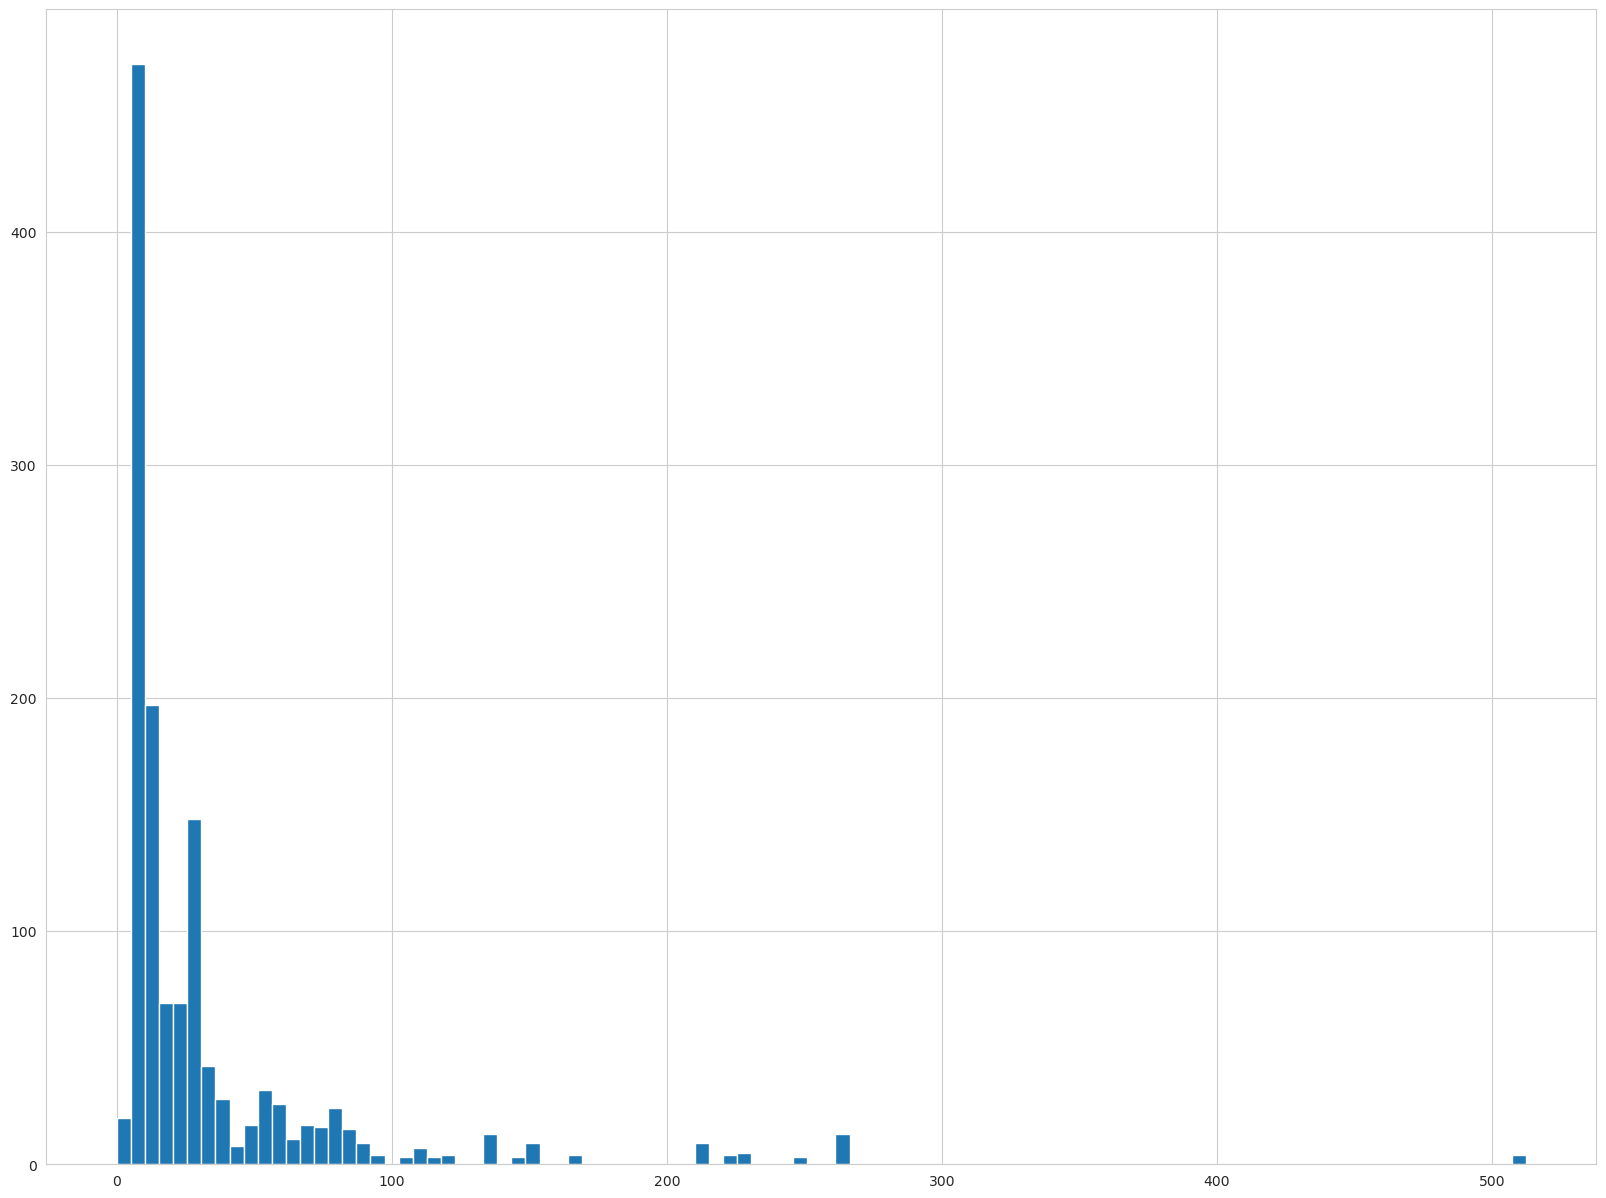

In [14]:
titanic2["fare"].hist(bins=100, figsize=(20, 15));

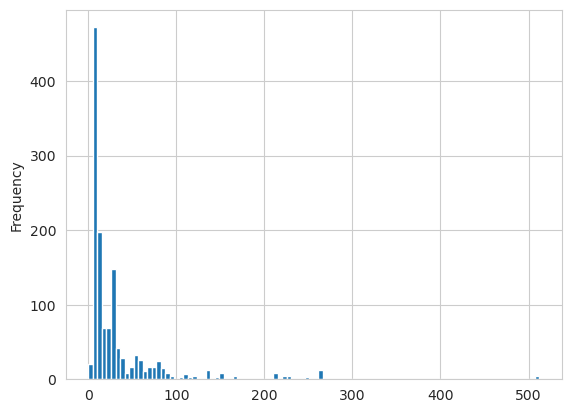

In [15]:
titanic2["fare"].plot(kind="hist", bins=100);

**Zoom sur la traîne.** On voit sur l'histogramme qu'il y a quelques billets très chers (le « bruit » à droite). Quelle **proportion** des voyageurs est concernée ? On filtre et on compte :

In [16]:
titanic2[titanic2["fare"] > 120].shape[0] / titanic2.shape[0]

0.05118411000763942

La proportion de voyageurs ayant payé plus de 120 est de l'ordre de **5%**.

> **5% d'outliers, c'est significatif.** Sur 1300 passagers, ça fait ~65 personnes. Ils ne sont pas des erreurs — ce sont de vrais riches qui ont acheté des suites luxueuses. Le **choix** qu'on fera à leur sujet (les garder ? les winsoriser ? les ignorer ?) dépend du modèle qu'on veut construire :
>
> - Pour prédire « le prix moyen du billet d'un voyageur quelconque », on peut les traiter comme une anomalie.
> - Pour prédire « le prix d'un billet de 1ère classe », au contraire, ce sont **eux** le signal.
>
> **Il n'y a pas de règle universelle** — c'est toujours une décision métier.

On peut regarder de plus près **l'allure de l'histogramme pour les faibles valeurs** de `fare`, en zoomant via un filtre. C'est souvent instructif : la distribution « normale » peut cacher des structures fines qu'on ne voit pas à pleine échelle.

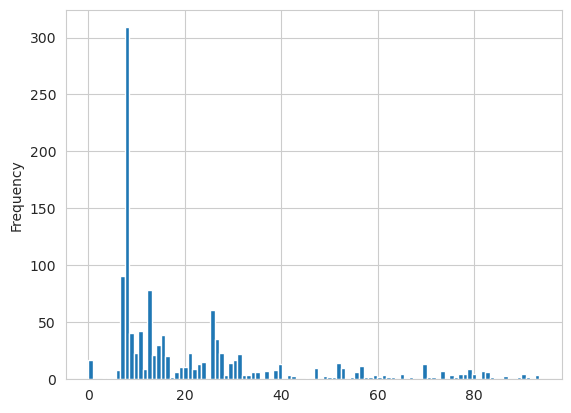

In [17]:
titanic2_low_fare = titanic2[titanic2["fare"] < 100]
titanic2_low_fare["fare"].plot(kind="hist", bins=100);

**Observation intéressante :** on voit clairement la présence de **regroupements par « paquets »** dans le prix des billets. C'est probablement lié à des **tarifs standardisés** : quelques prix communs partagés par de nombreux passagers d'une même classe ou d'un même port.

> **Pourquoi cela compte pour le ML ?** Un **arbre de décision** (ou n'importe quel modèle qui découpe par seuils) peut tirer parti de ces paliers : il va couper pile là où les paquets se séparent. Une régression linéaire, au contraire, verra ça comme du bruit sur une tendance continue — et sera moins efficace.
>
> **Morale :** observer la forme des histogrammes **influence directement le choix de l'algorithme**. Les EDA ne servent pas qu'à « décrire » les données : elles guident les décisions de modélisation.

**Seaborn** permet de représenter une **estimation de la densité de probabilité** en option avec `kde=True` (*Kernel Density Estimation*).

> **L'idée de la KDE :** au lieu de compter brutalement les valeurs dans des paquets (comme un histogramme), on « lisse » la distribution en posant une petite courbe en cloche sur chaque point et en additionnant. Résultat : une courbe continue qui donne une vision plus « naturelle » de la distribution, sans l'effet d'escalier des bins.
>
> Utile pour comparer visuellement deux distributions qui se superposent, ou pour estimer à quoi ressemble la « vraie » densité sous-jacente.

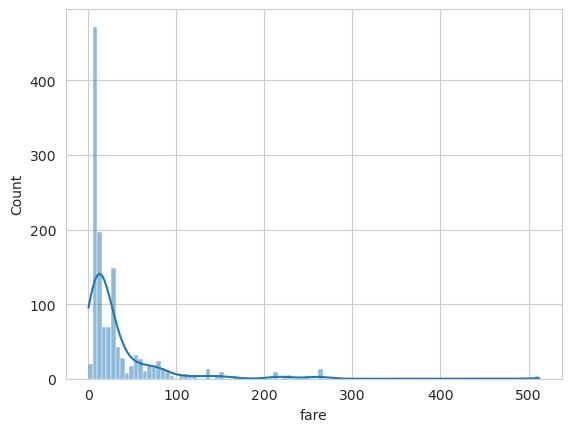

In [18]:
sns.histplot(data=titanic2, x="fare", bins=100, kde=True);

### Vue synthétique de toutes les variables numériques

Au lieu de tracer l'histogramme de chaque variable une par une, on peut utiliser directement la fonction **`hist()`** de pandas, qui le fait pour toutes les colonnes numériques d'un coup. Très pratique pour **repérer en 2 secondes** les variables problématiques (outliers, asymétrie, valeurs rares).

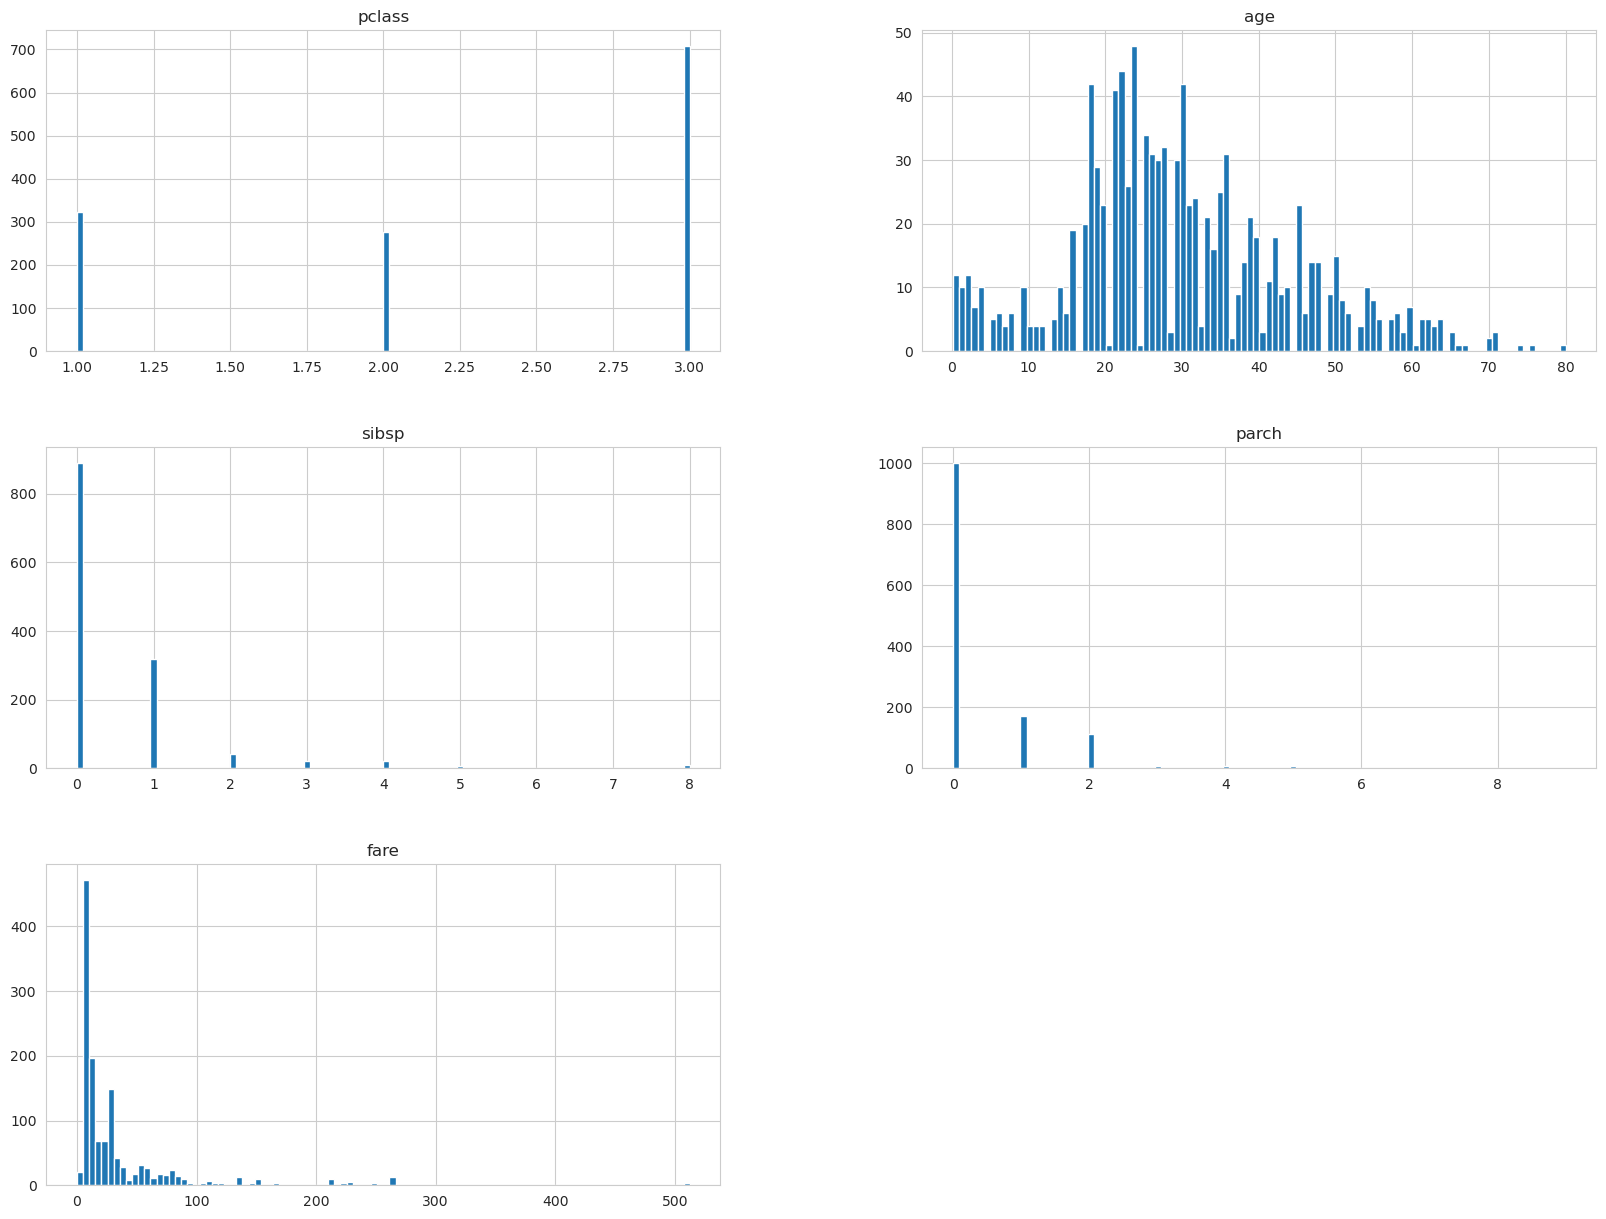

In [19]:
titanic2.hist(bins=100, figsize=(20, 15));

**Lecture guidée des histogrammes :**

- Ils **confirment** les impressions issues de l'étude de `describe()` — en particulier pour `fare` (longue traîne à droite évidente).
- Ils révèlent aussi que **d'autres attributs** ont une longue traîne à droite : `sibsp`, `parch`. Ces variables sont dominées par de petites valeurs et ont quelques passagers avec de grandes familles.
- **`age`** est à peu près symétrique, avec un mode vers 25-30 ans.
- **`pclass`** est trimodale (3 pics discrets aux valeurs 1, 2, 3).

> **🎯 Impact sur le ML :** les longues traînes compliquent la vie de certains algorithmes :
> - **Régression linéaire** : très sensible aux outliers, biaisée par la traîne. On applique souvent une **transformation log** (`np.log1p(df['fare'])`) pour « symétriser » la variable avant l'entraînement.
> - **KNN / SVM / réseaux de neurones** : sensibles à l'échelle — il faut normaliser (`StandardScaler`) ou robustifier (`RobustScaler`).
> - **Arbres et ensembles (Random Forest, Gradient Boosting)** : robustes à ces problèmes par construction. C'est une des raisons pour lesquelles ils dominent les compétitions sur données tabulaires.

### Boxplots

Les **boxplots** (boîtes à moustaches, ou *box-and-whisker plots*) sont une représentation **alternative et complémentaire** à l'histogramme. Ils sont plus compacts et montrent explicitement les quartiles et les outliers.

**Anatomie d'un boxplot :**

- La **boîte** représente l'**intervalle interquartile (IQR)** : de $Q_1$ (25e percentile) à $Q_3$ (75e percentile). **50% des données** sont dans cette boîte.
- La **ligne à l'intérieur** de la boîte est la **médiane** ($Q_2$, 50e percentile).
- Les **moustaches** s'étendent jusqu'à la dernière valeur qui n'est pas un outlier, dans la limite de $1{,}5 \times \text{IQR}$ de part et d'autre de la boîte.
- Les **points isolés** au-delà des moustaches sont, par convention, les **outliers** (*« valeurs aberrantes »*) : toute valeur au-delà de $Q_3 + 1{,}5 \times \text{IQR}$ ou en dessous de $Q_1 - 1{,}5 \times \text{IQR}$.

> **Pourquoi c'est utile ?** Un boxplot raconte en un coup d'œil :
> - la **valeur typique** (médiane) ;
> - la **dispersion centrale** (taille de la boîte) ;
> - la **symétrie** (médiane centrée ou pas dans la boîte) ;
> - la **présence d'outliers**.
>
> Idéal pour **comparer plusieurs groupes** d'un coup : `sns.boxplot(data=df, x='pclass', y='fare')` montre instantanément comment `fare` varie entre les classes.

Text(0.5, 1.0, "Distribution de l'âge")

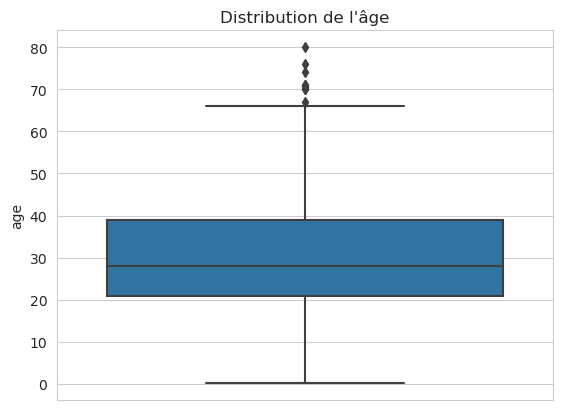

In [20]:
ax = sns.boxplot(data=titanic2, y="age")
ax.set_title("Distribution de l'âge")

## Variables catégorielles

Les techniques qu'on a utilisées ne marchent pas pour les variables catégorielles (pas de moyenne possible pour `sex` ou `embarked` !). On utilise à la place des **fréquences** et des **histogrammes par catégorie**.

In [21]:
titanic2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1046 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
dtypes: category(2), float64(2), int64(3)
memory usage: 54.1 KB


### Vue synthétique des variables catégorielles

`describe()` accepte un paramètre `include` qui permet de cibler un type spécifique de colonnes. Avec `include=['category']`, il nous donne pour chaque variable catégorielle :

- `count` : nombre de valeurs non-nulles ;
- `unique` : nombre de catégories distinctes ;
- `top` : la catégorie **la plus fréquente** (le **mode**) ;
- `freq` : le nombre d'occurrences de cette catégorie dominante.

C'est l'équivalent « catégoriel » des statistiques descriptives numériques.

In [22]:
titanic2.describe(include=['category'])

,sex,embarked
count,1309,1307
unique,2,3
top,male,S
freq,843,914


### Distribution des variables catégorielles

Pour chaque variable catégorielle, le réflexe est le même qu'en numérique : on regarde sa **distribution**, c'est-à-dire combien de voyageurs tombent dans chaque catégorie. On utilise `value_counts()` ou un **bar plot** (barre par catégorie) — l'équivalent de l'histogramme en catégoriel.

#### La variable `sex`

In [23]:
titanic2["sex"].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

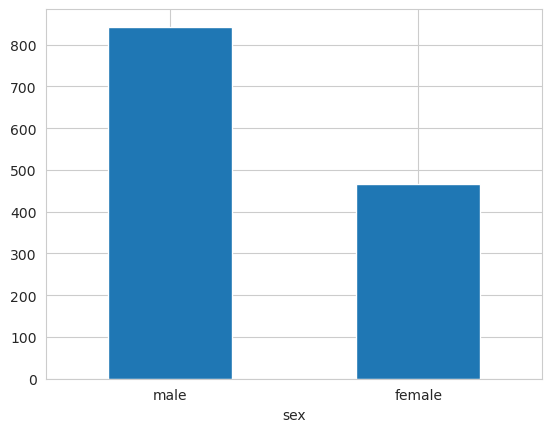

In [24]:
titanic2["sex"].value_counts().plot(kind="bar", rot=0);

**Alternative** : on peut aussi utiliser la fonction `hist()` de DataFrame pour obtenir un rendu rapide. Le résultat est moins propre qu'un vrai bar plot mais ça marche.

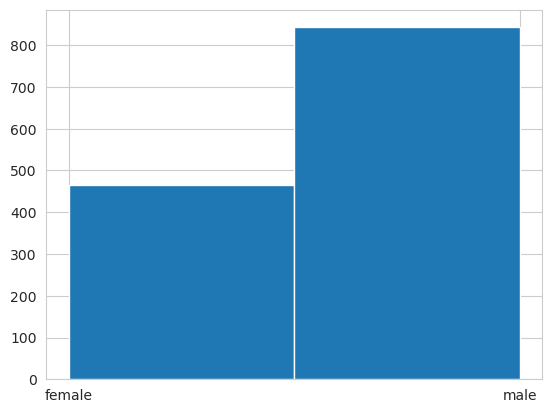

In [25]:
titanic2["sex"].hist(bins=2);

**Observation :** on constate qu'il y a **plus d'hommes que de femmes** parmi les voyageurs (ratio d'environ 2:1).

> **🎯 Pourquoi cette observation est critique sur ce dataset ?**
> Parce que l'évacuation du Titanic a suivi la règle **« les femmes et les enfants d'abord »**. Le sexe est donc un **prédicteur extrêmement fort** de la survie. Si on ne connaissait rien de ce dataset et qu'on ignorait `sex`, on passerait à côté de la variable la plus explicative.
>
> C'est un excellent rappel : **l'EDA ne se lit pas en isolation**. Chaque observation doit être mise en relation avec la **target** (`survived` ici) et avec le **contexte métier** (l'histoire du Titanic).

#### La variable `embarked`

Les trois ports de l'Atlantique : **C**herbourg, **Q**ueenstown, **S**outhampton.

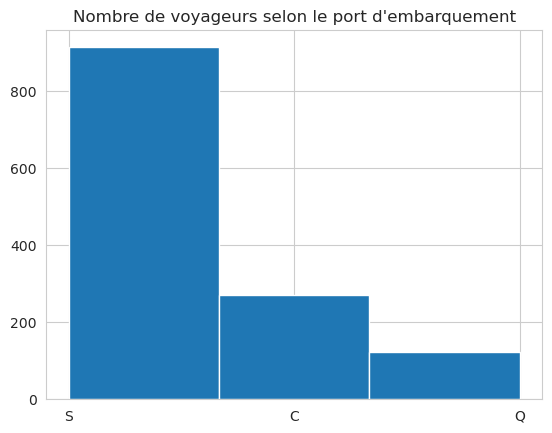

In [26]:
ax = titanic2["embarked"].hist(bins=3)
ax.set_title("Nombre de voyageurs selon le port d'embarquement");

**Avec seaborn** : la fonction `countplot()` fait exactement la même chose, avec un rendu plus soigné et plus facilement personnalisable (couleurs, tri, labels, *hue* pour croiser avec une autre variable…). C'est généralement le choix à privilégier pour une visualisation « publiable ».

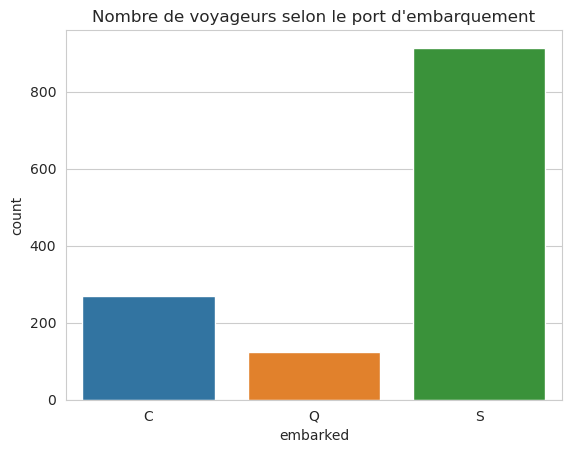

In [27]:
ax = sns.countplot(data=titanic2, x="embarked")
ax.set_title("Nombre de voyageurs selon le port d'embarquement");

#### La variable `survived` (la target)

On finit par la variable la plus importante : **la cible**. Avant de commencer à entraîner un modèle, il faut **toujours** regarder comment sont réparties les classes à prédire.

In [28]:
srv = survived.astype(np.int8)
srv.mean()

0.3819709702062643

**38% des voyageurs ont survécu, 62% ont péri.**

> **🎯 Pourquoi regarder l'équilibre des classes ?**
>
> C'est une **des premières questions** à se poser avant d'entraîner un classifieur. Selon le ratio :
>
> - **Proche de 50/50** (comme ici, 38/62) → pas d'action particulière nécessaire. L'accuracy est une métrique fiable, les algorithmes classiques marchent sans tuning spécial.
> - **70/30** à **90/10** → commencer à s'inquiéter. L'accuracy devient trompeuse — un modèle qui prédit toujours la classe majoritaire sera déjà à 90% d'accuracy sans rien apprendre. Utiliser plutôt **F1-score**, **AUC-ROC**, **précision/rappel**.
> - **99/1** ou pire (détection de fraude, maladies rares, anomalies) → **déséquilibre sévère**. Techniques à connaître :
>   - **Oversampling** de la classe minoritaire (SMOTE, ADASYN).
>   - **Undersampling** de la classe majoritaire.
>   - **Class weights** dans scikit-learn (`class_weight='balanced'`).
>   - Modèles dédiés (Isolation Forest, One-Class SVM pour la détection d'anomalie).
>
> **Sur le Titanic** : avec 38/62, on est dans la zone confortable. On peut utiliser l'accuracy, pas besoin de techniques spéciales. C'est une bonne nouvelle, mais ce ne sera pas toujours le cas en production !

## 🎯 Synthèse — la démarche d'analyse exploratoire

### La routine d'EDA en 7 étapes

Toujours la même séquence sur un nouveau dataset :

1. **`.shape`** → combien de lignes et de colonnes ?
2. **`.head()`** / **`.sample(5)`** → à quoi ressemblent les données « en vrai » ?
3. **`.info()`** → types des colonnes, valeurs manquantes, poids mémoire.
4. **`.isnull().sum()`** → carto des trous par colonne.
5. **`.describe()`** → statistiques descriptives numériques.
6. **`.describe(include='object')`** ou `.value_counts()` pour chaque catégorielle.
7. **Visualiser :** histogrammes pour le numérique, barplots pour le catégoriel, matrice de corrélation, pair-plots.

### Les questions à se poser systématiquement

- **La target est-elle équilibrée ?** → conditionne métrique et stratégie.
- **Y a-t-il des fuites de données ?** → variables qui encodent la target (comme `boat`/`body`).
- **Moyennes et médianes divergent-elles ?** → détecte les distributions asymétriques.
- **Les échelles des variables sont-elles homogènes ?** → si non, penser à la normalisation.
- **Quelles variables sont catégorielles vs numériques ?** → conditionne l'encodage.
- **Les variables à haute cardinalité méritent-elles du feature engineering ?** (texte, IDs…)

### Les pièges classiques

- ⚠️ **Se jeter sur un modèle sans EDA** : le piège numéro 1. On se retrouve avec un modèle qui marche pour de mauvaises raisons (fuite) ou qui ne marche pas du tout (données sales non détectées).
- ⚠️ **Faire l'EDA sur tout le dataset (train + test)** : ça introduit du **data leakage**. Les décisions d'exploration (seuils, imputations, valeurs de référence) doivent être prises uniquement sur le **train**, puis appliquées au test.
- ⚠️ **Confondre corrélation et causalité** : deux variables peuvent être corrélées sans qu'une cause l'autre. L'EDA identifie des patterns ; seuls le contexte métier et parfois des expériences contrôlées permettent de conclure.
- ⚠️ **Supprimer les outliers « par réflexe »** : avant de jeter une valeur extrême, se demander si elle représente une **vraie anomalie** (erreur de saisie, capteur cassé) ou un **signal important** (fraude, panne, cas intéressant).

### Outils à connaître pour aller plus loin

| Outil | Pour quoi faire ? |
|---|---|
| **`pandas-profiling` / `ydata-profiling`** | Rapport EDA complet automatique (1 ligne → 1 HTML riche). Idéal pour une première passe. |
| **`seaborn`** | Visualisations statistiques « prêtes à publier » : `pairplot`, `heatmap`, `boxplot`, `violinplot`. |
| **`sweetviz`** | Rapport EDA comparatif (train vs test, ou deux datasets). |
| **`missingno`** | Visualisation des patterns de valeurs manquantes (`msno.matrix(df)`). |

### Le mot de la fin

> **L'EDA n'est pas une case à cocher, c'est une conversation avec vos données.** Chaque question en amène une autre, chaque graphique soulève une hypothèse. Plus vous passez de temps à comprendre vos données, moins vous en passerez à déboguer vos modèles. Un data scientist passe **au moins 50% de son temps** à cette étape — et ce n'est pas du temps perdu, c'est ce qui distingue un modèle « qui tourne » d'un modèle « qui sert ».